# GNN Analysis for AI Lab Gene Expression Data

In this notebook, I try Graph Neural Networks on the AI Lab gene expression data.

I test two graph ideas:

1. **Cell graph GNN**
   - each node is one cell/sample
   - node features are gene expression values
   - edges connect similar cells
   - task: predict hypoxia vs normoxia

2. **Gene graph GNN**
   - each node is one gene
   - edges connect genes with similar expression patterns
   - task: predict whether a gene looks more hypoxia-associated or normoxia-associated

I use both:
- GCN
- GraphSAGE

I also include visual graph plots, training curves, accuracy, F1 score, and confusion matrices.

## 1. Install packages if needed

Run this only if something is missing.

`torch-geometric` can sometimes be difficult on Windows or with new GPUs.  
If GPU causes issues, this notebook can still run on CPU.

In [50]:
# !pip install torch numpy pandas matplotlib seaborn scikit-learn networkx umap-learn
# !pip install torch-geometric

## 2. Imports

Here I import the tools for data loading, graphs, GNN models, and evaluation.

In [51]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

import torch
from torch import nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import kneighbors_graph
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA

try:
    from torch_geometric.data import Data
    from torch_geometric.nn import GCNConv, SAGEConv
    from torch_geometric.utils import to_networkx
    TORCH_GEOMETRIC_AVAILABLE = True
except Exception as e:
    TORCH_GEOMETRIC_AVAILABLE = False
    print("torch-geometric could not be imported.")
    print("Error:", e)

sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)
print("torch-geometric available:", TORCH_GEOMETRIC_AVAILABLE)

Using device: cuda
torch-geometric available: True


## 3. Set the paths

Change `BASE` to your own local data folder.

In [52]:
BASE = Path(r"C:\Users\hugoo\OneDrive\Desktop\ai-lab-report\data")

SMART = BASE / "SmartSeq"
DROP = BASE / "DropSeq"

OUTPUT = BASE.parent / "gnn_outputs"
OUTPUT.mkdir(exist_ok=True)

print("SmartSeq exists:", SMART.exists())
print("DropSeq exists:", DROP.exists())
print("Output folder:", OUTPUT)

SmartSeq exists: True
DropSeq exists: True
Output folder: C:\Users\hugoo\OneDrive\Desktop\ai-lab-report\gnn_outputs


## 4. Helper functions for loading the data

These functions load expression files and create simple binary labels.

For this notebook:
- hypoxia = 1
- normoxia = 0

In [53]:
def load_expr(path):
    df = pd.read_csv(path, sep=r"\s+", engine="python", index_col=0)
    df.index = df.index.astype(str).str.replace('"', '', regex=False)
    df.columns = df.columns.astype(str).str.replace('"', '', regex=False)
    return df

def get_dropseq_condition(sample_name):
    if "Normoxia" in sample_name:
        return "Normoxia"
    if "Hypoxia" in sample_name:
        return "Hypoxia"
    return "Unknown"

def make_binary_labels(labels):
    return labels.astype(str).str.contains("Hyp", case=False, na=False).astype(int)

def prepare_xy(expr, labels):
    X = expr.T.copy()
    y = make_binary_labels(labels.loc[X.index])
    return X, y

## 5. Load the normalized training data

I use the normalized 3000-gene training files because they are already cleaner and better for machine learning.

In [54]:
smart_mcf7 = load_expr(SMART / "MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt")
smart_hcc = load_expr(SMART / "HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt")

drop_mcf7 = load_expr(DROP / "MCF7_Filtered_Normalised_3000_Data_train.txt")
drop_hcc = load_expr(DROP / "HCC1806_Filtered_Normalised_3000_Data_train.txt")

meta_mcf7 = pd.read_csv(SMART / "MCF7_SmartS_MetaData.tsv", sep="\t")
meta_hcc = pd.read_csv(SMART / "HCC1806_SmartS_MetaData.tsv", sep="\t")

meta_mcf7["Filename"] = meta_mcf7["Filename"].astype(str).str.replace('"', '', regex=False)
meta_hcc["Filename"] = meta_hcc["Filename"].astype(str).str.replace('"', '', regex=False)

smart_mcf7_labels = meta_mcf7.set_index("Filename").loc[smart_mcf7.columns, "Condition"]
smart_hcc_labels = meta_hcc.set_index("Filename").loc[smart_hcc.columns, "Condition"]

drop_mcf7_labels = pd.Series([get_dropseq_condition(c) for c in drop_mcf7.columns], index=drop_mcf7.columns)
drop_hcc_labels = pd.Series([get_dropseq_condition(c) for c in drop_hcc.columns], index=drop_hcc.columns)

datasets = {
    "SmartSeq_MCF7": (smart_mcf7, smart_mcf7_labels),
    "SmartSeq_HCC1806": (smart_hcc, smart_hcc_labels),
    "DropSeq_MCF7": (drop_mcf7, drop_mcf7_labels),
    "DropSeq_HCC1806": (drop_hcc, drop_hcc_labels),
}

for name, (expr, labels) in datasets.items():
    print(name, expr.shape, labels.value_counts().to_dict())

SmartSeq_MCF7 (3000, 250) {'Norm': 126, 'Hypo': 124}
SmartSeq_HCC1806 (3000, 182) {'Hypo': 97, 'Normo': 85}
DropSeq_MCF7 (3000, 21626) {'Normoxia': 12705, 'Hypoxia': 8921}
DropSeq_HCC1806 (3000, 14682) {'Hypoxia': 8899, 'Normoxia': 5783}


## 6. Choose the dataset

I can change this variable to run the same GNN workflow on another dataset.

In [55]:
DATASET_NAME = "SmartSeq_MCF7"

expr, labels = datasets[DATASET_NAME]
print("Selected dataset:", DATASET_NAME)
print("Expression shape:", expr.shape)
print(labels.value_counts())

Selected dataset: SmartSeq_MCF7
Expression shape: (3000, 250)
Condition
Norm    126
Hypo    124
Name: count, dtype: int64


# Part A: Cell Graph GNN

In this part, I build a graph where each node is a cell/sample.

The logic is:
- similar cells are connected
- each cell has its 3000 gene expression values as features
- the GNN predicts the condition of each cell

## 7. Build a cell graph

I connect each cell to its nearest neighbors based on expression similarity.

In [56]:
def build_cell_graph(expr, labels, k=10):
    X, y = prepare_xy(expr, labels)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    adjacency = kneighbors_graph(
        X_scaled,
        n_neighbors=k,
        mode="connectivity",
        include_self=False
    )
    adjacency = adjacency.maximum(adjacency.T)

    edge_index_np = np.vstack(adjacency.nonzero())

    data = Data(
        x=torch.tensor(X_scaled, dtype=torch.float32),
        edge_index=torch.tensor(edge_index_np, dtype=torch.long),
        y=torch.tensor(y.values, dtype=torch.long)
    )

    data.sample_names = list(X.index)
    data.gene_names = list(X.columns)

    return data, X, y, adjacency

cell_data, cell_X, cell_y, cell_adj = build_cell_graph(expr, labels, k=10)

print(cell_data)
print("Number of nodes:", cell_data.num_nodes)
print("Number of edges:", cell_data.num_edges)
print("Number of node features:", cell_data.num_features)

Data(x=[250, 3000], edge_index=[2, 4690], y=[250], sample_names=[250], gene_names=[3000])
Number of nodes: 250
Number of edges: 4690
Number of node features: 3000


## 8. Create train/validation/test masks

For GNNs, I split the nodes into training, validation, and test nodes.

In [57]:
def add_node_masks(data, y, train_size=0.7, val_size=0.15):
    indices = np.arange(data.num_nodes)

    train_idx, temp_idx = train_test_split(
        indices,
        train_size=train_size,
        random_state=SEED,
        stratify=y
    )

    val_relative = val_size / (1 - train_size)

    val_idx, test_idx = train_test_split(
        temp_idx,
        train_size=val_relative,
        random_state=SEED,
        stratify=y.iloc[temp_idx]
    )

    data.train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    data.val_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    data.test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)

    data.train_mask[train_idx] = True
    data.val_mask[val_idx] = True
    data.test_mask[test_idx] = True

    data.train_idx = train_idx
    data.val_idx = val_idx
    data.test_idx = test_idx

    return data

cell_data = add_node_masks(cell_data, cell_y)
cell_data = cell_data.to(DEVICE)

print("Train nodes:", int(cell_data.train_mask.sum()))
print("Val nodes:", int(cell_data.val_mask.sum()))
print("Test nodes:", int(cell_data.test_mask.sum()))

Train nodes: 175
Val nodes: 37
Test nodes: 38


In [58]:
train_idx = cell_data.train_idx
val_idx = cell_data.val_idx
test_idx = cell_data.test_idx

scaler = StandardScaler()

X_scaled = np.zeros_like(cell_X.values, dtype=np.float32)

X_scaled[train_idx] = scaler.fit_transform(cell_X.iloc[train_idx])
X_scaled[val_idx] = scaler.transform(cell_X.iloc[val_idx])
X_scaled[test_idx] = scaler.transform(cell_X.iloc[test_idx])

cell_data.x = torch.tensor(X_scaled, dtype=torch.float32).to(DEVICE)

print("Scaler refit only on training nodes.")
print("Feature matrix shape:", cell_data.x.shape)
print("Device:", cell_data.x.device)

Scaler refit only on training nodes.
Feature matrix shape: torch.Size([250, 3000])
Device: cuda:0


## 9. Visualize the cell graph

I plot a smaller version of the graph so it is easier to see.

The colors show:
- 0 = normoxia
- 1 = hypoxia

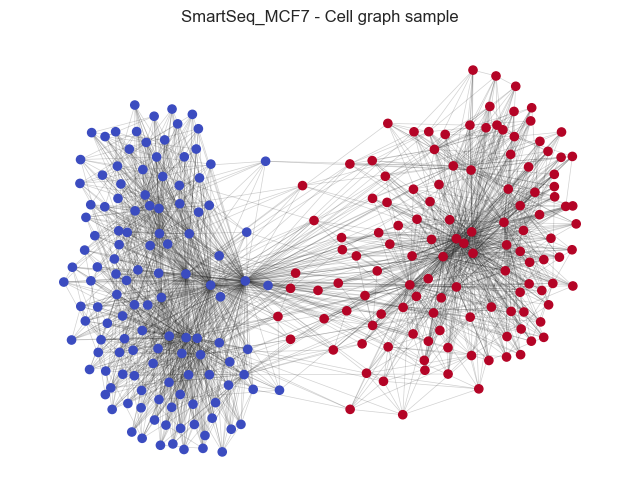

In [59]:
def plot_graph_sample(data, title, max_nodes=250):
    data_cpu = data.cpu()

    if data_cpu.num_nodes > max_nodes:
        selected = np.random.choice(data_cpu.num_nodes, max_nodes, replace=False)
        selected_set = set(selected)
        edge_index = data_cpu.edge_index.numpy()
        keep_edges = [
            i for i in range(edge_index.shape[1])
            if edge_index[0, i] in selected_set and edge_index[1, i] in selected_set
        ]
        G = nx.Graph()
        G.add_nodes_from(selected)
        for i in keep_edges:
            G.add_edge(edge_index[0, i], edge_index[1, i])
        node_colors = [int(data_cpu.y[n]) for n in G.nodes()]
    else:
        G = to_networkx(data_cpu, to_undirected=True)
        node_colors = [int(data_cpu.y[n]) for n in G.nodes()]

    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=SEED)
    nx.draw_networkx_nodes(G, pos, node_size=35, node_color=node_colors, cmap="coolwarm")
    nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.5)
    plt.title(title)
    plt.axis("off")
    plt.show()

plot_graph_sample(cell_data, f"{DATASET_NAME} - Cell graph sample")

## 10. Define GCN and GraphSAGE

GCN and GraphSAGE both use neighbors in the graph.

- GCN is the simpler baseline.
- GraphSAGE is a bit more flexible and often works well on bigger graphs.

In [60]:
class GCNNodeClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=2, dropout=0.3):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.out = GCNConv(hidden_dim, output_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.out(x, edge_index)
        return x

class GraphSAGENodeClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=2, dropout=0.3):
        super().__init__()
        self.conv1 = SAGEConv(input_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        self.out = SAGEConv(hidden_dim, output_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.out(x, edge_index)
        return x

## 11. Training and evaluation functions

These functions train the GNN and calculate accuracy/F1.

In [61]:
def train_gnn_node_classifier(model, data, epochs=150, lr=1e-3, weight_decay=1e-4):
    model = model.to(DEVICE)
    data = data.to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])

        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits = model(data.x, data.edge_index)
            pred = logits.argmax(dim=1)

            train_acc = accuracy_score(
                data.y[data.train_mask].cpu().numpy(),
                pred[data.train_mask].cpu().numpy()
            )
            val_acc = accuracy_score(
                data.y[data.val_mask].cpu().numpy(),
                pred[data.val_mask].cpu().numpy()
            )
            val_f1 = f1_score(
                data.y[data.val_mask].cpu().numpy(),
                pred[data.val_mask].cpu().numpy()
            )

        history.append({
            "epoch": epoch,
            "loss": float(loss.item()),
            "train_accuracy": train_acc,
            "val_accuracy": val_acc,
            "val_f1": val_f1
        })

        if epoch == 1 or epoch % 25 == 0:
            print(
                f"Epoch {epoch:03d} | loss {loss.item():.4f} | "
                f"train acc {train_acc:.3f} | val acc {val_acc:.3f}"
            )

    return pd.DataFrame(history)

def evaluate_gnn_node_classifier(model, data, split="test"):
    model = model.to(DEVICE)
    data = data.to(DEVICE)

    model.eval()
    mask = getattr(data, f"{split}_mask")

    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        pred = logits.argmax(dim=1)

    y_true = data.y[mask].cpu().numpy()
    y_pred = pred[mask].cpu().numpy()

    print(classification_report(y_true, y_pred, target_names=["Normoxia", "Hypoxia"]))
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred)
    }, pd.DataFrame({"true": y_true, "pred": y_pred})

## 12. Train GCN on the cell graph

In [62]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gcn_cell = GCNNodeClassifier(
    input_dim=cell_data.num_features,
    hidden_dim=64,
    output_dim=2
).to(DEVICE)

cell_data = cell_data.to(DEVICE)

gcn_cell_history = train_gnn_node_classifier(gcn_cell, cell_data, epochs=150)
gcn_cell_metrics, gcn_cell_preds = evaluate_gnn_node_classifier(
    gcn_cell, cell_data, split="test"
)

Epoch 001 | loss 0.8076 | train acc 0.503 | val acc 0.514
Epoch 025 | loss 0.0221 | train acc 0.994 | val acc 1.000
Epoch 050 | loss 0.0089 | train acc 1.000 | val acc 1.000
Epoch 075 | loss 0.0132 | train acc 1.000 | val acc 1.000
Epoch 100 | loss 0.0062 | train acc 1.000 | val acc 1.000
Epoch 125 | loss 0.0039 | train acc 1.000 | val acc 1.000
Epoch 150 | loss 0.0034 | train acc 1.000 | val acc 1.000
              precision    recall  f1-score   support

    Normoxia       1.00      1.00      1.00        19
     Hypoxia       1.00      1.00      1.00        19

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

Confusion matrix:
[[19  0]
 [ 0 19]]


## 13. Train GraphSAGE on the cell graph

In [63]:
sage_cell = GraphSAGENodeClassifier(input_dim=cell_data.num_features, hidden_dim=64, output_dim=2)
sage_cell_history = train_gnn_node_classifier(sage_cell, cell_data, epochs=150)
sage_cell_metrics, sage_cell_preds = evaluate_gnn_node_classifier(sage_cell, cell_data, split="test")

sage_cell_history.to_csv(OUTPUT / f"{DATASET_NAME}_cell_graphsage_history.csv", index=False)
sage_cell_preds.to_csv(OUTPUT / f"{DATASET_NAME}_cell_graphsage_predictions.csv", index=False)

sage_cell_metrics

Epoch 001 | loss 0.7168 | train acc 0.994 | val acc 1.000
Epoch 025 | loss 0.0015 | train acc 1.000 | val acc 1.000
Epoch 050 | loss 0.0002 | train acc 1.000 | val acc 1.000
Epoch 075 | loss 0.0000 | train acc 1.000 | val acc 1.000
Epoch 100 | loss 0.0001 | train acc 1.000 | val acc 1.000
Epoch 125 | loss 0.0001 | train acc 1.000 | val acc 1.000
Epoch 150 | loss 0.0002 | train acc 1.000 | val acc 1.000
              precision    recall  f1-score   support

    Normoxia       1.00      1.00      1.00        19
     Hypoxia       1.00      1.00      1.00        19

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

Confusion matrix:
[[19  0]
 [ 0 19]]


{'accuracy': 1.0, 'f1': 1.0}

## 14. Plot cell GNN training curves

This helps me see if the models are learning normally.

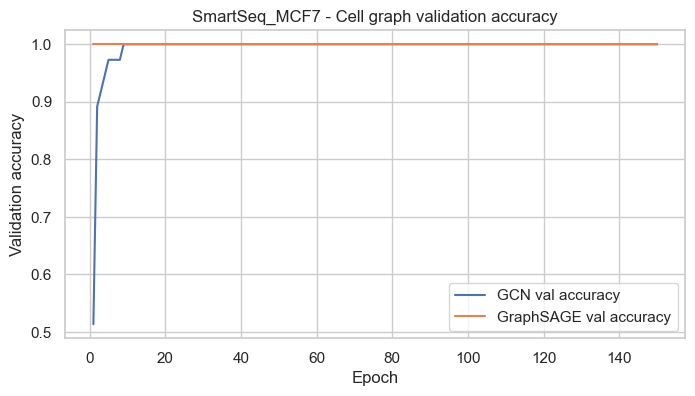

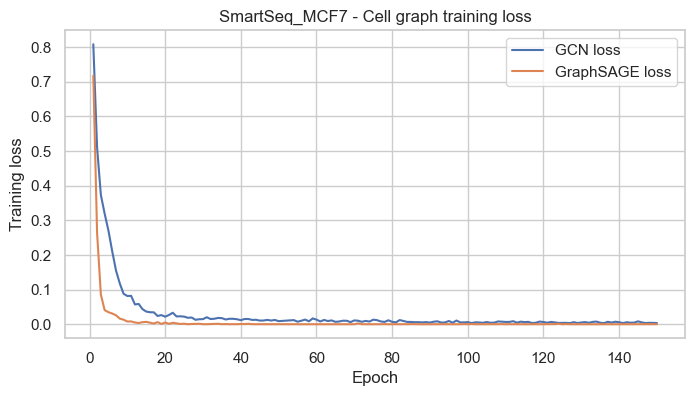

In [64]:
plt.figure(figsize=(8, 4))
plt.plot(gcn_cell_history["epoch"], gcn_cell_history["val_accuracy"], label="GCN val accuracy")
plt.plot(sage_cell_history["epoch"], sage_cell_history["val_accuracy"], label="GraphSAGE val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title(f"{DATASET_NAME} - Cell graph validation accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(gcn_cell_history["epoch"], gcn_cell_history["loss"], label="GCN loss")
plt.plot(sage_cell_history["epoch"], sage_cell_history["loss"], label="GraphSAGE loss")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title(f"{DATASET_NAME} - Cell graph training loss")
plt.legend()
plt.show()

## 15. Cell GNN comparison

In [65]:
cell_gnn_comparison = pd.DataFrame([
    {"graph": "cell_graph", "model": "GCN", **gcn_cell_metrics},
    {"graph": "cell_graph", "model": "GraphSAGE", **sage_cell_metrics},
])

cell_gnn_comparison.to_csv(OUTPUT / f"{DATASET_NAME}_cell_gnn_comparison.csv", index=False)
cell_gnn_comparison

,graph,model,accuracy,f1
0,cell_graph,GCN,1.0,1.0
1,cell_graph,GraphSAGE,1.0,1.0


# Part B: Gene Graph GNN

Now I build a graph where each node is a gene.

This is more experimental because the gene labels are created from the data itself.

The graph is based on gene-gene expression similarity, not a known pathway database.

## 16. Create simple gene labels

I label a gene as:

- 1 if its average expression is higher in hypoxia
- 0 if its average expression is higher in normoxia

This is simple and useful for exploration, but it is not a formal differential expression test.

In [66]:
def make_gene_labels(expr, labels):
    condition = labels.loc[expr.columns]
    hyp_cols = condition[condition.astype(str).str.contains("Hyp", case=False, na=False)].index
    norm_cols = condition[condition.astype(str).str.contains("Norm", case=False, na=False)].index

    hyp_mean = expr[hyp_cols].mean(axis=1)
    norm_mean = expr[norm_cols].mean(axis=1)
    gene_label = (hyp_mean > norm_mean).astype(int)

    diff_df = pd.DataFrame({
        "mean_hypoxia": hyp_mean,
        "mean_normoxia": norm_mean,
        "diff": hyp_mean - norm_mean,
        "gene_label": gene_label
    })
    return gene_label, diff_df

gene_labels, gene_diff_df = make_gene_labels(expr, labels)
print(gene_labels.value_counts())
display(gene_diff_df.head())

0    1509
1    1491
Name: count, dtype: int64


,mean_hypoxia,mean_normoxia,diff,gene_label
CYP1B1,10696.193548,296.079365,10400.114183,1
CYP1B1-AS1,4430.491935,121.126984,4309.364951,1
CYP1A1,3233.911290,1.111111,3232.800179,1
NDRG1,1203.637097,18.603175,1185.033922,1
DDIT4,4663.588710,344.960317,4318.628392,1


## 17. Build the gene graph

Each node is a gene.

Each gene's features are its expression values across cells.  
I connect genes with similar expression patterns.

In [67]:
def build_gene_graph(expr, labels, k=10, max_genes=1000):
    gene_label, diff_df = make_gene_labels(expr, labels)

    # I keep only the most variable genes so the graph stays manageable.
    if expr.shape[0] > max_genes:
        selected_genes = expr.var(axis=1).sort_values(ascending=False).head(max_genes).index
        expr_sub = expr.loc[selected_genes]
        gene_label = gene_label.loc[selected_genes]
        diff_df = diff_df.loc[selected_genes]
    else:
        expr_sub = expr.copy()

    X = expr_sub.copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    adjacency = kneighbors_graph(
        X_scaled,
        n_neighbors=k,
        mode="connectivity",
        include_self=False
    )
    adjacency = adjacency.maximum(adjacency.T)

    edge_index_np = np.vstack(adjacency.nonzero())

    data = Data(
        x=torch.tensor(X_scaled, dtype=torch.float32),
        edge_index=torch.tensor(edge_index_np, dtype=torch.long),
        y=torch.tensor(gene_label.values, dtype=torch.long)
    )
    data.gene_names = list(expr_sub.index)

    return data, expr_sub, gene_label, diff_df, adjacency

gene_data, gene_expr_sub, gene_y, gene_diff_sub, gene_adj = build_gene_graph(expr, labels, k=10, max_genes=1000)

print(gene_data)
print("Number of gene nodes:", gene_data.num_nodes)
print("Number of edges:", gene_data.num_edges)
print("Number of features per gene:", gene_data.num_features)

Data(x=[1000, 250], edge_index=[2, 18578], y=[1000], gene_names=[1000])
Number of gene nodes: 1000
Number of edges: 18578
Number of features per gene: 250


## 18. Create masks for gene nodes

In [68]:
gene_data = add_node_masks(gene_data, gene_y)
gene_data = gene_data.to(DEVICE)

print("Train gene nodes:", int(gene_data.train_mask.sum()))
print("Val gene nodes:", int(gene_data.val_mask.sum()))
print("Test gene nodes:", int(gene_data.test_mask.sum()))

Train gene nodes: 700
Val gene nodes: 149
Test gene nodes: 151


## 19. Visualize the gene graph

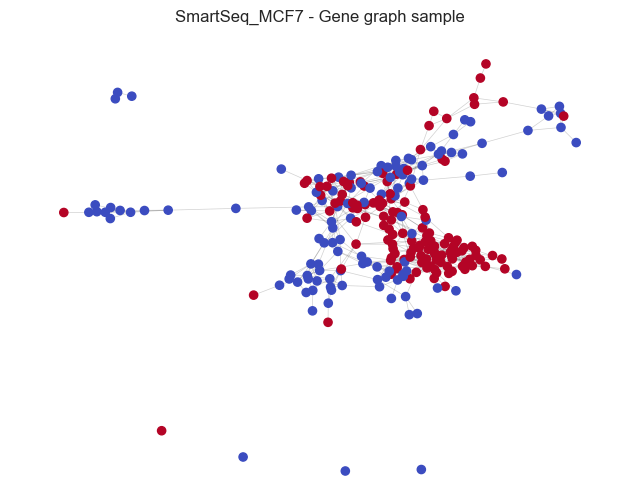

In [69]:
plot_graph_sample(gene_data, f"{DATASET_NAME} - Gene graph sample", max_nodes=250)

## 20. Train GCN on the gene graph

In [70]:
gcn_gene = GCNNodeClassifier(input_dim=gene_data.num_features, hidden_dim=64, output_dim=2)
gcn_gene_history = train_gnn_node_classifier(gcn_gene, gene_data, epochs=150)
gcn_gene_metrics, gcn_gene_preds = evaluate_gnn_node_classifier(gcn_gene, gene_data, split="test")

gcn_gene_history.to_csv(OUTPUT / f"{DATASET_NAME}_gene_gcn_history.csv", index=False)
gcn_gene_preds.to_csv(OUTPUT / f"{DATASET_NAME}_gene_gcn_predictions.csv", index=False)

gcn_gene_metrics

Epoch 001 | loss 0.7082 | train acc 0.787 | val acc 0.785
Epoch 025 | loss 0.3138 | train acc 0.879 | val acc 0.899
Epoch 050 | loss 0.2311 | train acc 0.909 | val acc 0.899
Epoch 075 | loss 0.2126 | train acc 0.917 | val acc 0.913
Epoch 100 | loss 0.1972 | train acc 0.916 | val acc 0.913
Epoch 125 | loss 0.1885 | train acc 0.917 | val acc 0.919
Epoch 150 | loss 0.1780 | train acc 0.924 | val acc 0.933
              precision    recall  f1-score   support

    Normoxia       0.90      0.96      0.93        73
     Hypoxia       0.96      0.90      0.93        78

    accuracy                           0.93       151
   macro avg       0.93      0.93      0.93       151
weighted avg       0.93      0.93      0.93       151

Confusion matrix:
[[70  3]
 [ 8 70]]


{'accuracy': 0.9271523178807947, 'f1': 0.9271523178807947}

## 21. Train GraphSAGE on the gene graph

In [71]:
sage_gene = GraphSAGENodeClassifier(input_dim=gene_data.num_features, hidden_dim=64, output_dim=2)
sage_gene_history = train_gnn_node_classifier(sage_gene, gene_data, epochs=150)
sage_gene_metrics, sage_gene_preds = evaluate_gnn_node_classifier(sage_gene, gene_data, split="test")

sage_gene_history.to_csv(OUTPUT / f"{DATASET_NAME}_gene_graphsage_history.csv", index=False)
sage_gene_preds.to_csv(OUTPUT / f"{DATASET_NAME}_gene_graphsage_predictions.csv", index=False)

sage_gene_metrics

Epoch 001 | loss 0.7118 | train acc 0.531 | val acc 0.537
Epoch 025 | loss 0.2330 | train acc 0.904 | val acc 0.919
Epoch 050 | loss 0.1754 | train acc 0.933 | val acc 0.926
Epoch 075 | loss 0.1318 | train acc 0.946 | val acc 0.940
Epoch 100 | loss 0.1027 | train acc 0.954 | val acc 0.946
Epoch 125 | loss 0.0871 | train acc 0.980 | val acc 0.966
Epoch 150 | loss 0.0450 | train acc 0.989 | val acc 0.973
              precision    recall  f1-score   support

    Normoxia       0.94      0.99      0.96        73
     Hypoxia       0.99      0.94      0.96        78

    accuracy                           0.96       151
   macro avg       0.96      0.96      0.96       151
weighted avg       0.96      0.96      0.96       151

Confusion matrix:
[[72  1]
 [ 5 73]]


{'accuracy': 0.9602649006622517, 'f1': 0.9605263157894737}

## 22. Plot gene GNN training curves

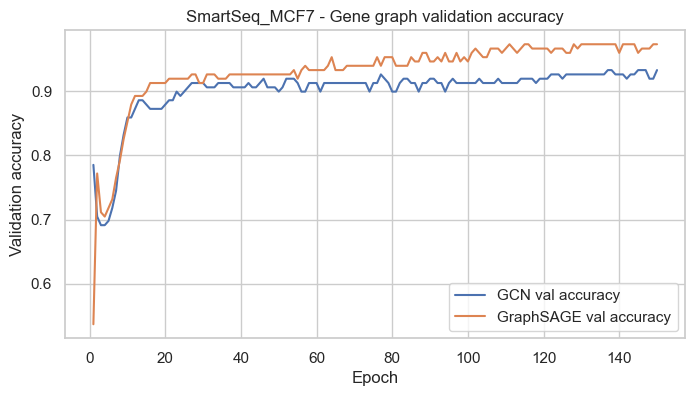

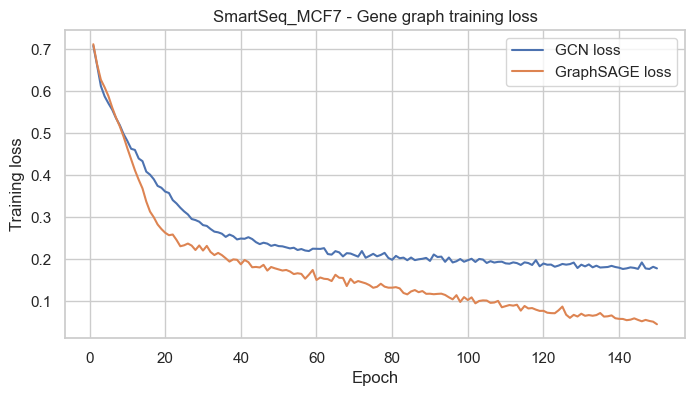

In [72]:
plt.figure(figsize=(8, 4))
plt.plot(gcn_gene_history["epoch"], gcn_gene_history["val_accuracy"], label="GCN val accuracy")
plt.plot(sage_gene_history["epoch"], sage_gene_history["val_accuracy"], label="GraphSAGE val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title(f"{DATASET_NAME} - Gene graph validation accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(gcn_gene_history["epoch"], gcn_gene_history["loss"], label="GCN loss")
plt.plot(sage_gene_history["epoch"], sage_gene_history["loss"], label="GraphSAGE loss")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title(f"{DATASET_NAME} - Gene graph training loss")
plt.legend()
plt.show()

## 23. Gene GNN comparison

In [73]:
gene_gnn_comparison = pd.DataFrame([
    {"graph": "gene_graph", "model": "GCN", **gcn_gene_metrics},
    {"graph": "gene_graph", "model": "GraphSAGE", **sage_gene_metrics},
])

gene_gnn_comparison.to_csv(OUTPUT / f"{DATASET_NAME}_gene_gnn_comparison.csv", index=False)
gene_gnn_comparison

,graph,model,accuracy,f1
0,gene_graph,GCN,0.927152,0.927152
1,gene_graph,GraphSAGE,0.960265,0.960526


## 24. Combined GNN results

In [74]:
all_gnn_results = pd.concat([cell_gnn_comparison, gene_gnn_comparison], ignore_index=True)
all_gnn_results.to_csv(OUTPUT / f"{DATASET_NAME}_all_gnn_results.csv", index=False)
all_gnn_results

,graph,model,accuracy,f1
0,cell_graph,GCN,1.000000,1.000000
1,cell_graph,GraphSAGE,1.000000,1.000000
2,gene_graph,GCN,0.927152,0.927152
3,gene_graph,GraphSAGE,0.960265,0.960526


## 25. Bar plots for GNN results

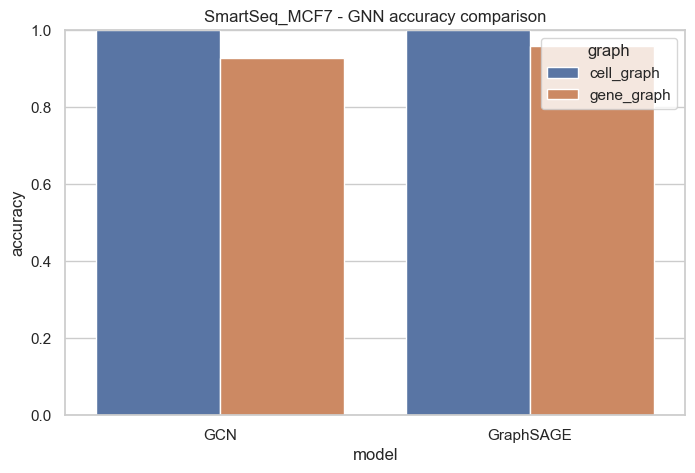

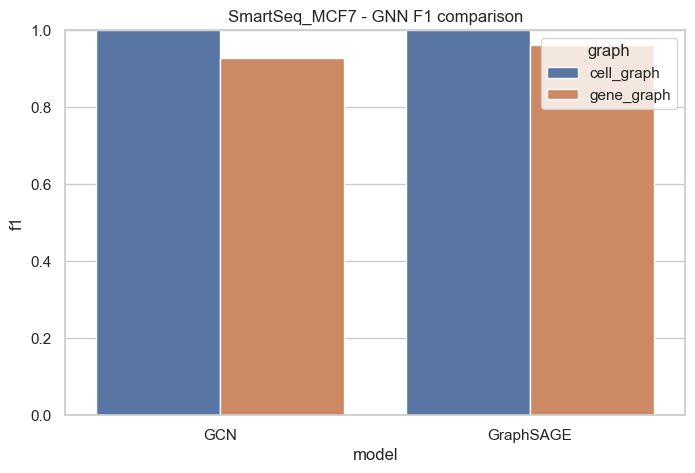

In [75]:
plt.figure(figsize=(8, 5))
sns.barplot(data=all_gnn_results, x="model", y="accuracy", hue="graph")
plt.ylim(0, 1)
plt.title(f"{DATASET_NAME} - GNN accuracy comparison")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=all_gnn_results, x="model", y="f1", hue="graph")
plt.ylim(0, 1)
plt.title(f"{DATASET_NAME} - GNN F1 comparison")
plt.show()

## 26. Visualize GNN embeddings

Here I extract hidden embeddings from the GCN and plot them with PCA.

This helps me see whether the GNN learned a useful structure.

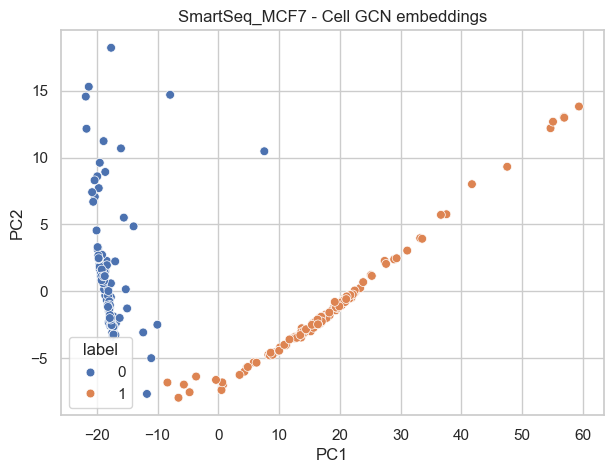

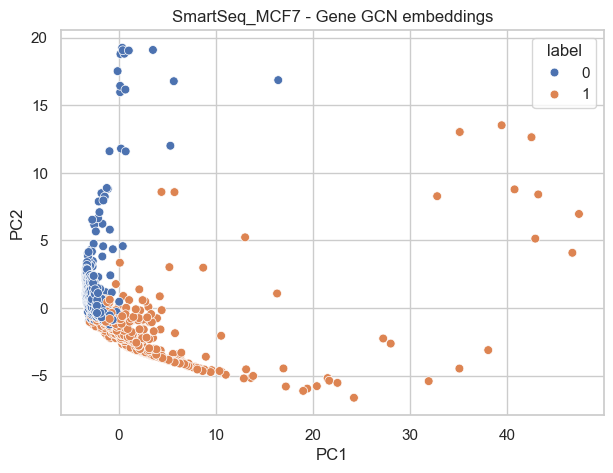

In [76]:
class GCNEmbeddingExtractor(nn.Module):
    def __init__(self, trained_model):
        super().__init__()
        self.trained_model = trained_model

    def get_embedding(self, x, edge_index):
        model = self.trained_model
        model.eval()
        with torch.no_grad():
            x = model.conv1(x, edge_index)
            x = F.relu(x)
            x = model.conv2(x, edge_index)
            x = F.relu(x)
        return x

def plot_gnn_embeddings(model, data, title):
    emb_model = GCNEmbeddingExtractor(model)
    emb = emb_model.get_embedding(data.x, data.edge_index).detach().cpu().numpy()

    pcs = PCA(n_components=2, random_state=SEED).fit_transform(emb)

    plot_df = pd.DataFrame({
        "PC1": pcs[:, 0],
        "PC2": pcs[:, 1],
        "label": data.y.detach().cpu().numpy()
    })

    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="label", s=40)
    plt.title(title)
    plt.show()

    return plot_df

cell_embedding_df = plot_gnn_embeddings(gcn_cell, cell_data, f"{DATASET_NAME} - Cell GCN embeddings")
gene_embedding_df = plot_gnn_embeddings(gcn_gene, gene_data, f"{DATASET_NAME} - Gene GCN embeddings")

cell_embedding_df.to_csv(OUTPUT / f"{DATASET_NAME}_cell_gcn_embeddings.csv", index=False)
gene_embedding_df.to_csv(OUTPUT / f"{DATASET_NAME}_gene_gcn_embeddings.csv", index=False)

## GNN Results and Discussion

The cell graph achieved perfect performance for both GCN and GraphSAGE, reaching an accuracy and F1 score of 1.00 on the test set. Initially, I found these results somewhat suspicious because perfect classification is uncommon in most machine learning problems. However, after examining the PCA projection, graph visualizations, confusion matrices, and training curves, the results appear reasonable for this dataset.

The visualizations show a strong separation between normoxia and hypoxia cells, suggesting that the biological signal is highly informative. The confusion matrices further confirm this observation, as all test samples were classified correctly by both models. Even after correcting the feature scaling procedure to avoid fitting the scaler on the full dataset, the results remained unchanged, indicating that the high performance is likely due to the strong separability of the two conditions rather than preprocessing issues.

The gene graph produced slightly lower but still very strong results. GCN achieved approximately 93% accuracy and F1 score, while GraphSAGE achieved approximately 96%. Unlike the cell graph, where each node directly represents a cell with its full expression profile, the gene graph requires the model to learn relationships between genes and infer the biological condition indirectly. This makes the classification task more challenging and explains the lower performance.

Comparing the two architectures, GraphSAGE consistently performed at least as well as GCN and achieved the best results on the gene graph. This suggests that GraphSAGE was better able to capture information from neighboring nodes and learn meaningful representations from the graph structure.

Overall, the results indicate that hypoxia and normoxia are highly distinguishable in this dataset. The cell graph provides near-perfect separation between conditions, while the gene graph presents a more challenging and arguably more realistic classification task. Despite the increased difficulty, both GNN architectures achieved strong predictive performance, with GraphSAGE emerging as the best-performing model overall.